# <b>Cluster Data</b>
The preprocessed matrix is subjected to unsupervised clustering to identify transcriptionally distinct cell populations in the data.

---

## 1. Setup Environment

### 1.1. Import Libraries

In [1]:
from PIL import Image

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scanpy as sc

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import compute_sample_weight

### 1.2. Define File Paths/Directories

In [2]:
import config

# Preprocessed AnnData file
PREPROCESSED_ANNDATA_FILE = config.PROCESSED_DATA_DIR / "Norman_2019_preprocessed.h5ad"
print("Preprocessed AnnData file:\n", PREPROCESSED_ANNDATA_FILE)

# Clustered AnnData file save directory
CLUSTERED_ANNDATA_FILE = config.PROCESSED_DATA_DIR / "Norman_2019_clustered.h5ad"
print("\nClustered AnnData file will be saved to:\n", CLUSTERED_ANNDATA_FILE)

# Figures save directory
FIGURES_DIR = config.FIGURES_DIR
print("\nFigures will be saved to:\n", FIGURES_DIR)

Preprocessed AnnData file:
 ..\01_data\02_processed\Norman_2019_preprocessed.h5ad

Clustered AnnData file will be saved to:
 ..\01_data\02_processed\Norman_2019_clustered.h5ad

Figures will be saved to:
 ..\03_figures


### 1.3. Define Global Parameters

In [3]:
SEED = config.SEED

np.random.seed(SEED)
sc.settings.seed = SEED

print(f"\nRandom seed set to: {SEED}")


Random seed set to: 42


---

## 2. Load And Validate Data

### 2.1. Load Preprocessed AnnData

In [4]:
# Read the preprocessed AnnData file
print("\nReading preprocessed AnnData file...")
adata = sc.read_h5ad(PREPROCESSED_ANNDATA_FILE)
print(adata)


Reading preprocessed AnnData file...
AnnData object with n_obs × n_vars = 100047 × 19996
    obs: 'guide_identity', 'read_count', 'UMI_count', 'coverage', 'gemgroup', 'good_coverage', 'number_of_cells', 'guide_AHR', 'guide_ARID1A', 'guide_ARRDC3', 'guide_ATL1', 'guide_BAK1', 'guide_BCL2L11', 'guide_BCORL1', 'guide_BPGM', 'guide_C19orf26', 'guide_C3orf72', 'guide_CBFA2T3', 'guide_CBL', 'guide_CDKN1A', 'guide_CDKN1B', 'guide_CDKN1C', 'guide_CEBPA', 'guide_CEBPB', 'guide_CEBPE', 'guide_CELF2', 'guide_CITED1', 'guide_CKS1B', 'guide_CLDN6', 'guide_CNN1', 'guide_CNNM4', 'guide_COL1A1', 'guide_COL2A1', 'guide_CSRNP1', 'guide_DLX2', 'guide_DUSP9', 'guide_EGR1', 'guide_ELMSAN1', 'guide_ETS2', 'guide_FEV', 'guide_FOSB', 'guide_FOXA1', 'guide_FOXA3', 'guide_FOXF1', 'guide_FOXL2', 'guide_FOXO4', 'guide_GLB1L2', 'guide_HES7', 'guide_HK2', 'guide_HNF4A', 'guide_HOXA13', 'guide_HOXB9', 'guide_HOXC13', 'guide_IER5L', 'guide_IGDCC3', 'guide_IKZF3', 'guide_IRF1', 'guide_ISL2', 'guide_JUN', 'guide_KIAA1

### 2.2. Inspect Data

In [5]:
print("Cell IDs:\n", adata.obs_names)
print("\nGene IDs:\n", adata.var_names)

print("\nGene symbols:\n", adata.var.gene_symbols)

print("\nSample data matrix (first 5 rows and columns):\n", adata.X[:5, :5].toarray())

Cell IDs:
 Index(['AAACCTGAGGCATGTG-1', 'AAACCTGAGGCCCTTG-1', 'AAACCTGCACGAAGCA-1',
       'AAACCTGCAGCCTTGG-1', 'AAACCTGCATCTCCCA-1', 'AAACCTGCATTACCTT-1',
       'AAACCTGGTATAATGG-1', 'AAACCTGGTATCGCAT-1', 'AAACCTGGTATGAAAC-1',
       'AAACCTGGTCCATCCT-1',
       ...
       'TTTGTCAGTATAAACG-8', 'TTTGTCAGTCACTTCC-8', 'TTTGTCAGTCAGAATA-8',
       'TTTGTCAGTCATGCAT-8', 'TTTGTCAGTCCATGAT-8', 'TTTGTCATCACTCCTG-8',
       'TTTGTCATCAGTACGT-8', 'TTTGTCATCCACTCCA-8', 'TTTGTCATCCCAACGG-8',
       'TTTGTCATCTGGCGAC-8'],
      dtype='object', name='index', length=100047)

Gene IDs:
 Index(['RP11-34P13.3', 'RP11-34P13.7', 'FO538757.3', 'FO538757.2',
       'AP006222.2', 'RP4-669L17.10', 'RP5-857K21.4', 'RP11-206L10.9',
       'LINC00115', 'FAM41C',
       ...
       'AC136616.1', 'BX004987.4', 'AC145212.4', 'AC145212.2', 'AC011043.1',
       'AL592183.1', 'AC007325.4', 'AL354822.1', 'AC004556.1', 'AC240274.1'],
      dtype='object', length=19996)

Gene symbols:
 RP11-34P13.3    RP11-34P13.3
RP1

### 2.3. Validate Data

#### 2.3.1. Verify Normalization and HVG Selection

In [6]:
# Verify normalization
x_max = adata.X.data.max()
x_min = adata.X.data.min()
assert x_min >= 0, "Negative values found — normalization error"
assert (
    x_max <= np.log1p(1e4) + 0.01
), f"Max value {x_max:.3f} exceeds log1p(10000) — log1p may not have been applied"
print(f"Normalization and log1p verified (value range: {x_min:.3f} - {x_max:.3f})")

# Verify raw counts layer preserved
assert "counts" in adata.layers, "Raw counts layer missing"
assert np.all(
    adata.layers["counts"].data == np.floor(adata.layers["counts"].data)
), "Raw counts layer contains non-integers"
print("Raw counts layer preserved")

# Verify HVGs selected
assert adata.var["highly_variable"].sum() == 3000, "HVG count mismatch"
print("HVGs selected: 3000")

print("\nAll assertions passed.")

Normalization and log1p verified (value range: 0.323 - 8.399)
Raw counts layer preserved
HVGs selected: 3000

All assertions passed.


#### 2.3.2. Index Genes By Symbol
Index genes by their symbols instead of Ensembl IDs.

In [7]:
# Check if genes are already indexed by their symbols
are_genes_ens_ids = adata.var_names.str.startswith("ENSG").all()

# Map to gene symbols if currently indexed by Ensembl IDs
if are_genes_ens_ids:
    print("\nGenes are indexed by Ensembl IDs. Mapping to gene symbols....")

    # Check if gene symbols are unique
    if adata.var.gene_symbols.is_unique:
        print("Gene symbols are unique. Setting gene symbols as index....")
        adata.var_names = adata.var['gene_symbols'].values
        print("\nGene symbols set as index successfully.")
    else:
        print("\nGene symbols are NOT unique.")

        # How many duplicates?
        duplicates = adata.var['gene_symbols'][adata.var['gene_symbols'].duplicated(keep=False)]
        print(f"Number of duplicate gene symbol entries: {len(duplicates)}")
        print(duplicates.value_counts().head())

        # Make gene symbols unique by appending a suffix to duplicates
        print("\nMaking gene symbols unique and setting them as index....")
        adata.var_names = adata.var['gene_symbols'].values
        adata.var_names_make_unique()
        print("Gene symbols made unique and set as index successfully.")

# If genes are already indexed by gene symbols, no mapping is needed
else:
    print("\nGenes are already indexed by gene symbols. No mapping needed.")

print("\nGene IDs:\n", adata.var_names)


Genes are already indexed by gene symbols. No mapping needed.

Gene IDs:
 Index(['RP11-34P13.3', 'RP11-34P13.7', 'FO538757.3', 'FO538757.2',
       'AP006222.2', 'RP4-669L17.10', 'RP5-857K21.4', 'RP11-206L10.9',
       'LINC00115', 'FAM41C',
       ...
       'AC136616.1', 'BX004987.4', 'AC145212.4', 'AC145212.2', 'AC011043.1',
       'AL592183.1', 'AC007325.4', 'AL354822.1', 'AC004556.1', 'AC240274.1'],
      dtype='object', length=19996)


#### 2.3.4. Verify Uniqueness Of Cell IDs

In [8]:
are_cell_ids_unique = adata.obs_names.is_unique

if are_cell_ids_unique:
    print("\nCell IDs are unique.")
else:
    print("\nFAILED: Cell IDs are NOT unique.")


Cell IDs are unique.


---

## 3. Cluster Data

### 3.1. Perform Dimensionality Reduction On HVGs


Performing PCA on highly variable genes...

PCA complete: 50 components computed


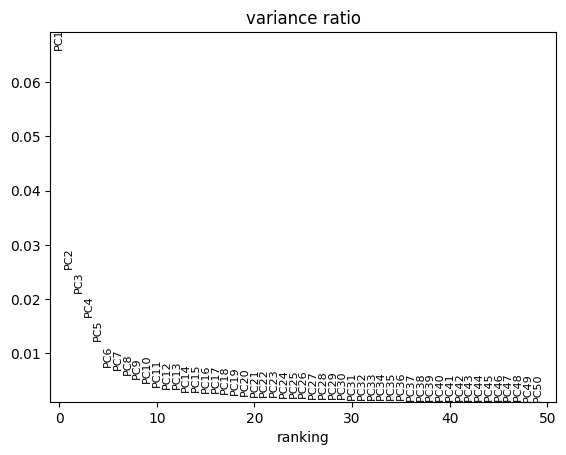

In [9]:
# Perform PCA on highly variable genes
print("\nPerforming PCA on highly variable genes...")
sc.tl.pca(adata, n_comps=50, mask_var='highly_variable', random_state=SEED)
print(f"\nPCA complete: {adata.obsm['X_pca'].shape[1]} components computed")

# Plot and save PCA variance ratio
sc.pl.pca_variance_ratio(adata, n_pcs=50, show=False)
plt.savefig(str(config.FIGURES_DIR / "04_pca_variance_ratio.png"), bbox_inches="tight")
plt.show()

### 3.2. Create Neighbor Graph
Since the PCA variance ratio plot has its elbow at `PC6`, a slightly higher number i.e. `n_pcs=10` is used here.

In [10]:
print("\nComputing neighbors graph...")
sc.pp.neighbors(adata, n_pcs=10, random_state=SEED)
print("Neighbors graph computed.")


Computing neighbors graph...
Neighbors graph computed.


### 3.3. Plot UMAPs

#### 3.3.1. Compute UMAP

In [11]:
sc.tl.umap(adata, random_state=SEED)
print("UMAP computed.")

UMAP computed.


#### 3.3.2. Plot Perturbation Identity UMAP

##### 3.3.2.1. Examine Guide Identity Values

In [12]:
print(adata.obs["guide_identity"].value_counts().head(20))

guide_identity
NegCtrl10_NegCtrl0__NegCtrl10_NegCtrl0    3164
NegCtrl1_NegCtrl0__NegCtrl1_NegCtrl0      2644
NegCtrl11_NegCtrl0__NegCtrl11_NegCtrl0    2535
NegCtrl0_NegCtrl0__NegCtrl0_NegCtrl0      2249
CEBPE_RUNX1T1__CEBPE_RUNX1T1              1111
KLF1_NegCtrl0__KLF1_NegCtrl0              1047
TBX3_TBX2__TBX3_TBX2                      1033
ETS2_CNN1__ETS2_CNN1                       837
SLC4A1_NegCtrl0__SLC4A1_NegCtrl0           835
DUSP9_ETS2__DUSP9_ETS2                     740
NegCtrl0_ETS2__NegCtrl0_ETS2               699
DUSP9_NegCtrl0__DUSP9_NegCtrl0             692
UBASH3B_OSR2__UBASH3B_OSR2                 690
NegCtrl0_BAK1__NegCtrl0_BAK1               670
NegCtrl0_KLF1__NegCtrl0_KLF1               654
LHX1_ELMSAN1__LHX1_ELMSAN1                 604
BAK1_NegCtrl0__BAK1_NegCtrl0               602
CBL_NegCtrl0__CBL_NegCtrl0                 601
NegCtrl0_CEBPE__NegCtrl0_CEBPE             595
LYL1_IER5L__LYL1_IER5L                     589
Name: count, dtype: int64


##### 3.3.2.2. Create Clean Perturbation Labels

In [13]:
print("\nCreating clean perturbation labels...")


def simplify_perturbation(label):
    # Take first half of A_B__A_B format, then extract gene names
    first_half = label.split("__")[0]
    parts = first_half.split("_")
    genes = [p for p in parts if not p.startswith("NegCtrl")]
    if len(genes) == 0:
        return "Control"
    return "_".join(genes)


adata.obs["perturbation_clean"] = adata.obs["guide_identity"].apply(
    simplify_perturbation
)
print(adata.obs["perturbation_clean"].value_counts().head(20))


Creating clean perturbation labels...
perturbation_clean
Control          10592
KLF1              1701
BAK1              1272
ETS2              1118
CEBPE_RUNX1T1     1111
CEBPE             1101
UBASH3B           1067
TBX3_TBX2         1033
OSR2               895
SET                866
ETS2_CNN1          837
SLC4A1             835
ELMSAN1            808
C19orf26           806
FOXF1              783
FOXA1              779
MAP2K6             756
DUSP9_ETS2         740
UBASH3A            730
MAPK1              717
Name: count, dtype: int64


##### 3.3.2.3. Plot UMAP Colored By Perturbations Of Interest

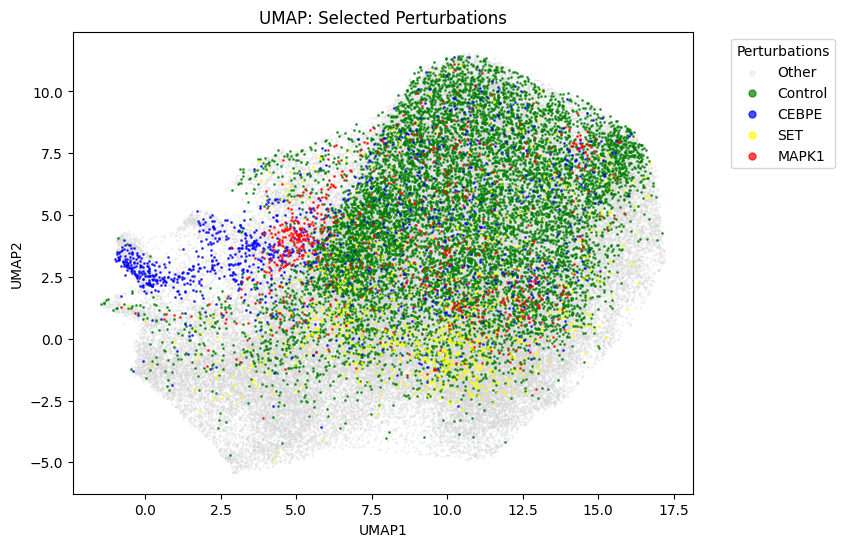

In [14]:
perturbations_of_interest = ["Control", "CEBPE", "SET", "MAPK1"]

adata.obs["perturbation_focus"] = adata.obs["perturbation_clean"].apply(
    lambda x: x if x in perturbations_of_interest else "Other"
)

fig, ax = plt.subplots(figsize=(8, 6))

# Plot 'Other' cells in light grey background first
other_mask = adata.obs["perturbation_focus"] == "Other"
ax.scatter(
    adata.obsm["X_umap"][other_mask, 0],
    adata.obsm["X_umap"][other_mask, 1],
    c="lightgrey",
    s=0.5,
    alpha=0.3,
    label="Other",
)

# Plot perturbations of interest on top
colors = {
    "Control": "green",
    "CEBPE": "blue",
    "SET": "yellow",
    "MAPK1": "red",
}
for perturbation, color in colors.items():
    mask = adata.obs["perturbation_focus"] == perturbation
    ax.scatter(
        adata.obsm["X_umap"][mask, 0],
        adata.obsm["X_umap"][mask, 1],
        c=color,
        s=1,
        alpha=0.7,
        label=perturbation,
    )

ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("UMAP: Selected Perturbations")
ax.legend(markerscale=5, bbox_to_anchor=(1.05, 1), title="Perturbations")
plt.savefig(str(FIGURES_DIR / "05_umap_perturbation.png"), bbox_inches="tight")
plt.show()

#### 3.3.3. Plot Cell Cycle Phase UMAP

##### 3.3.3.1. Score Cell Cycle Phases

In [15]:
# Tirosh et al. 2016 cell cycle gene lists
print("Scoring cell cycle phases using Tirosh et al. 2016 gene lists...")
s_genes = [
    'MCM5', 'PCNA', 'TYMS', 'FEN1', 'MCM2', 'MCM4', 'RRM1', 'UNG',
    'GINS2', 'MCM6', 'CDCA7', 'DTL', 'PRIM1', 'UHRF1', 'MLF1IP',
    'HELLS', 'RFC2', 'RPA2', 'NASP', 'RAD51AP1', 'GMNN', 'WDR76',
    'SLBP', 'CCNE2', 'UBR7', 'POLD3', 'MSH2', 'ATAD2', 'RAD51',
    'RRM2', 'CDC45', 'CDC6', 'EXO1', 'TIPIN', 'DSCC1', 'BLM',
    'CASP8AP2', 'USP1', 'CLSPN', 'POLA1', 'CHAF1B', 'BRIP1', 'E2F8'
]

g2m_genes = [
    'HMGB2', 'CDK1', 'NUSAP1', 'UBE2C', 'BIRC5', 'TPX2', 'TOP2A',
    'NDC80', 'CKS2', 'NUF2', 'CKS1B', 'MKI67', 'TMPO', 'CENPF',
    'TACC3', 'FAM64A', 'SMC4', 'CCNB2', 'CKAP2L', 'CKAP2', 'AURKB',
    'BUB1', 'KIF11', 'ANP32E', 'TUBB4B', 'GTSE1', 'KIF20B', 'HJURP',
    'CDCA3', 'HN1', 'CDC20', 'TTK', 'CDC25C', 'KIF2C', 'RANGAP1',
    'NCAPD2', 'DLGAP5', 'CDCA2', 'CDCA8', 'ECT2', 'KIF23', 'HMMR',
    'AURKA', 'PSRC1', 'ANLN', 'LBR', 'CKAP5', 'CENPE', 'CTCF',
    'NEK2', 'G2E3', 'GAS2L3', 'CBX5', 'CENPA'
]

# Filter to genes present in dataset
s_genes = [g for g in s_genes if g in adata.var_names]
g2m_genes = [g for g in g2m_genes if g in adata.var_names]

print(f"S phase genes found: {len(s_genes)}/43")
print(f"G2M phase genes found: {len(g2m_genes)}/54")

# Score cell cycle
sc.tl.score_genes_cell_cycle(adata, s_genes=s_genes, g2m_genes=g2m_genes)
print(adata.obs['phase'].value_counts())

Scoring cell cycle phases using Tirosh et al. 2016 gene lists...
S phase genes found: 42/43
G2M phase genes found: 54/54
phase
G2M    58135
S      21308
G1     20604
Name: count, dtype: int64


##### 3.3.3.2. Plot UMAP Colored By Cell Cycle Phases

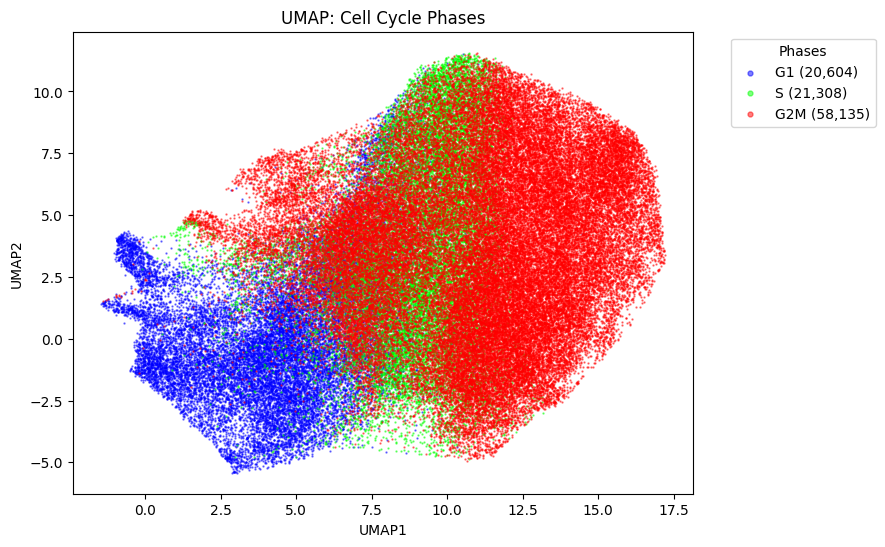

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))

phase_colors = {"G1": "blue", "S": "lime", "G2M": "red"}

for phase, color in phase_colors.items():
    mask = adata.obs["phase"] == phase
    ax.scatter(
        adata.obsm["X_umap"][mask, 0],
        adata.obsm["X_umap"][mask, 1],
        c=color,
        s=0.5,
        alpha=0.5,
        label=f"{phase} ({mask.sum():,})",
    )

ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("UMAP: Cell Cycle Phases")
ax.legend(markerscale=5, bbox_to_anchor=(1.05, 1), loc="upper left", title="Phases")
plt.savefig(str(config.FIGURES_DIR / "06_umap_cellcyclephase.png"), bbox_inches="tight")
plt.show()

#### 3.3.4. Plot Leiden Cluster UMAP

##### 3.3.4.1. Perform Leiden Partitioning

In [17]:
# Perform Leiden partitioning
print("\nPerforming Leiden partitioning...")
sc.tl.leiden(adata, resolution=0.5, flavor='igraph', n_iterations=2, directed=False, random_state=SEED)
print(f"Leiden partitioning complete.")

print(f"\nNumber of clusters: {adata.obs['leiden'].nunique()}")
print(adata.obs["leiden"].value_counts())


Performing Leiden partitioning...
Leiden partitioning complete.

Number of clusters: 8
leiden
1    25163
0    22539
2    18401
4    15182
5    11468
6     3901
3     1990
7     1403
Name: count, dtype: int64


##### 3.3.4.2. Plot UMAP Colored By Leiden Clusters

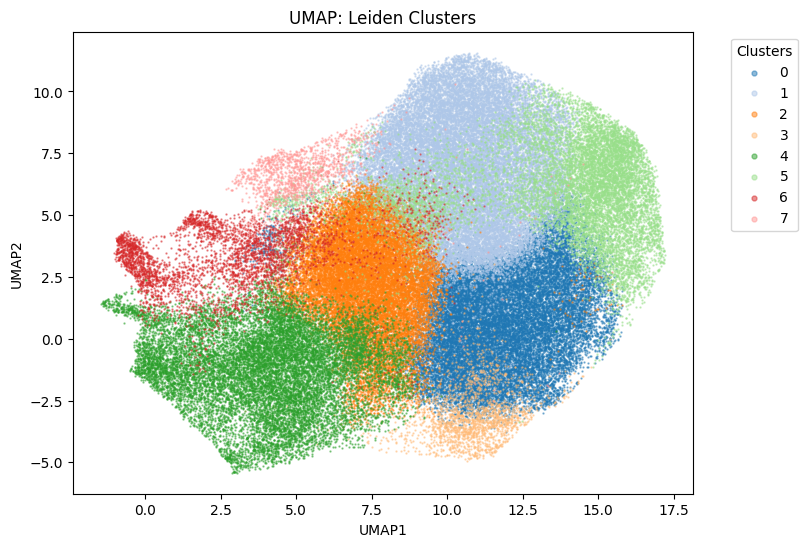

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))

leiden_categories = adata.obs["leiden"].cat.categories
colors_leiden = plt.cm.tab20.colors

for i, cluster in enumerate(leiden_categories):
    mask = adata.obs["leiden"] == cluster
    ax.scatter(
        adata.obsm["X_umap"][mask, 0],
        adata.obsm["X_umap"][mask, 1],
        c=[colors_leiden[i % 10]],
        s=0.5,
        alpha=0.5,
        label=cluster,
    )

ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("UMAP: Leiden Clusters")
ax.legend(markerscale=5, bbox_to_anchor=(1.05, 1), loc="upper left", title="Clusters")
plt.savefig(str(FIGURES_DIR / "07_umap_leiden.png"), bbox_inches="tight")
plt.show()

### 3.4. Compare UMAPs

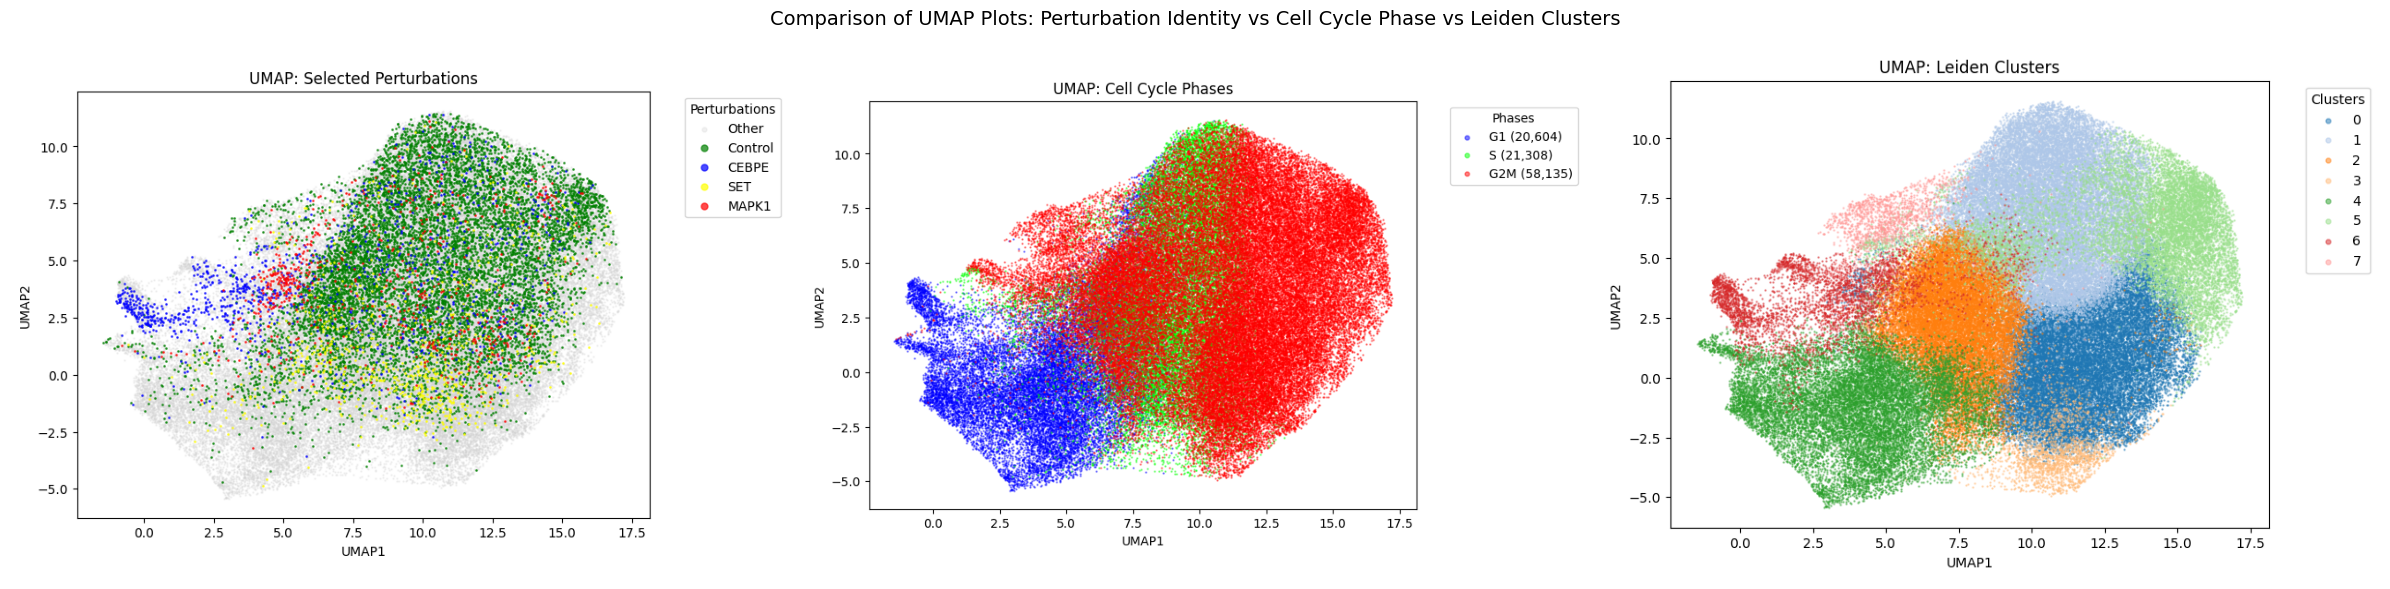

In [19]:
img1 = Image.open(FIGURES_DIR / "05_umap_perturbation.png")
img2 = Image.open(FIGURES_DIR / "06_umap_cellcyclephase.png")
img3 = Image.open(FIGURES_DIR / "07_umap_leiden.png")

fig, axes = plt.subplots(1, 3, figsize=(24, 6))
axes[0].imshow(img1)
axes[0].axis("off")

axes[1].imshow(img2)
axes[1].axis("off")

axes[2].imshow(img3)
axes[2].axis("off")

plt.suptitle("Comparison of UMAP Plots: Perturbation Identity vs Cell Cycle Phase vs Leiden Clusters", fontsize=14)
plt.tight_layout()
plt.savefig(str(FIGURES_DIR / "08_umap_comparison.png"), bbox_inches="tight")
plt.show()

Comparing the three UMAP plots, **`CEBPE` (blue in the perturbation plot)** is the only perturbation showing a clear and distinct transcriptional shift. CEBPE-perturbed cells are strongly enriched in **Leiden cluster 6 (red in the Leiden plot)**, which spatially corresponds to the left protrusion of the UMAP across all three colorings: perturbation identity, cell cycle stage, and unsupervised clustering all independently agree on this region being distinct.

Within cluster 6, CEBPE cells span G1 (left protrusion) and G2M (right protrusion) phases, with very few S phase cells, consistent with CEBPE overactivation potentially slowing cell cycle progression through differentiation signaling.

**`SET`** and **`MAPK1`** show no meaningful spatial separation from control cells and will not be pursued further. **`CEBPE`** is therefore the sole focus of downstream differential expression and pathway enrichment analysis.

### 3.5. Perform Variance Decomposition
Quantify how much of the transcriptional variation across cells is explained by cell cycle phase and perturbation identity respectively.

#### 3.5.1. Subset To CEBPE And Control Cells Only

In [20]:
print("\nSubsetting to CEBPE and Control cells for variance decomposition...")
mask_subset = adata.obs["perturbation_clean"].isin(["CEBPE", "Control"])
pca_coords = adata.obsm["X_pca"][mask_subset, :10]
phase_subset = adata.obs["phase"][mask_subset]
perturb_subset = adata.obs["perturbation_clean"][mask_subset]
print(
    f"Subset: {mask_subset.sum():,} cells (CEBPE: {(adata.obs['perturbation_clean']=='CEBPE').sum():,}, Control: {(adata.obs['perturbation_clean']=='Control').sum():,})"
)


Subsetting to CEBPE and Control cells for variance decomposition...
Subset: 11,693 cells (CEBPE: 1,101, Control: 10,592)


#### 3.5.2. Encode Perturbation And Cell Cycle Phases

In [21]:
le = LabelEncoder()
# Encode perturbation as numeric
print("\nEncoding perturbation and cell cycle phase as numeric for regression...")
perturb_encoded = le.fit_transform(perturb_subset).reshape(-1, 1)
phases_encoded = le.fit_transform(phase_subset).reshape(-1, 1)
print("Encoding complete.")

# Balance CEBPE vs Control class imbalance
print("\nBalancing class weights for perturbation...")
weights = compute_sample_weight("balanced", perturb_subset)
unique_classes, counts = np.unique(perturb_subset, return_counts=True)
for clss, count in zip(unique_classes, counts):
    print(
        f"  {clss}: {count:,} cells, weight = {weights[perturb_subset.values == clss][0]:.4f}"
    )


Encoding perturbation and cell cycle phase as numeric for regression...
Encoding complete.

Balancing class weights for perturbation...
  CEBPE: 1,101 cells, weight = 5.3102
  Control: 10,592 cells, weight = 0.5520


#### 3.5.3. Compute R² For Each Principle Component For Each Variable

In [22]:
print(
    "\nComputing R² for each principal component for perturbation and cell cycle phase..."
)
r2_perturb = []
r2_cellcycle = []

for i in range(10):
    pc = pca_coords[:, i].reshape(-1, 1)
    r2_perturb.append(
        LinearRegression()
        .fit(perturb_encoded, pc, sample_weight=weights)
        .score(perturb_encoded, pc, sample_weight=weights)
    )
    r2_cellcycle.append(
        LinearRegression()
        .fit(phases_encoded, pc, sample_weight=weights)
        .score(phases_encoded, pc, sample_weight=weights)
    )

for i, (r2p, r2c) in enumerate(zip(r2_perturb, r2_cellcycle)):
    print(f"PC{i+1:2d} — Cell Cycle: {r2c:.3f}  Perturbation: {r2p:.3f}")


Computing R² for each principal component for perturbation and cell cycle phase...
PC 1 — Cell Cycle: 0.239  Perturbation: 0.203
PC 2 — Cell Cycle: 0.122  Perturbation: 0.319
PC 3 — Cell Cycle: 0.000  Perturbation: 0.108
PC 4 — Cell Cycle: 0.028  Perturbation: 0.029
PC 5 — Cell Cycle: 0.082  Perturbation: 0.019
PC 6 — Cell Cycle: 0.019  Perturbation: 0.240
PC 7 — Cell Cycle: 0.017  Perturbation: 0.159
PC 8 — Cell Cycle: 0.153  Perturbation: 0.167
PC 9 — Cell Cycle: 0.025  Perturbation: 0.240
PC10 — Cell Cycle: 0.016  Perturbation: 0.063


#### 3.5.4. Plot Variance Decomposition Graph

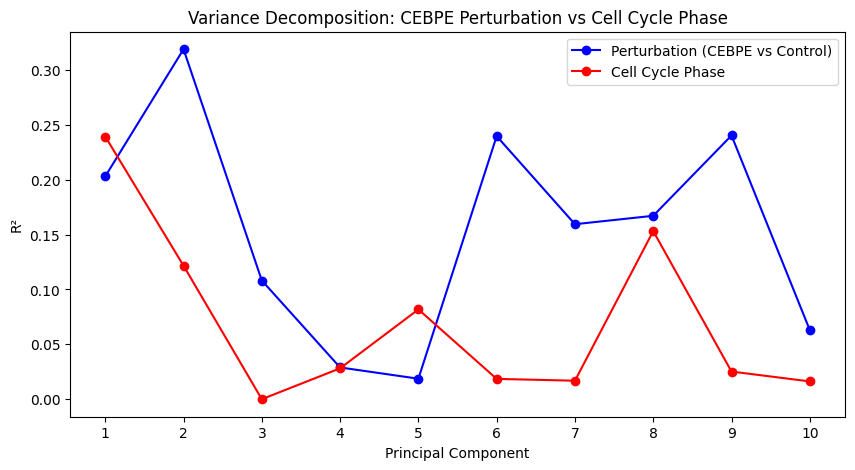

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
x = range(1, 11)
ax.plot(
    x, r2_perturb, marker="o", label="Perturbation (CEBPE vs Control)", color="blue"
)
ax.plot(x, r2_cellcycle, marker="o", label="Cell Cycle Phase", color="red")
ax.set_xlabel("Principal Component")
ax.set_ylabel("R²")
ax.set_title("Variance Decomposition: CEBPE Perturbation vs Cell Cycle Phase")
ax.set_xticks(range(1, 11))
ax.legend()
plt.savefig(
    str(config.FIGURES_DIR / "09_variance_decomposition.png"), bbox_inches="tight"
)
plt.show()

Variance decomposition was performed on the subset of CEBPE-perturbed and control cells (1,101 and 10,592 cells respectively) with class-balanced sample weights to account for the size imbalance between groups.

Cell cycle phase dominates **PC1** (R²=0.239 vs 0.203), confirming it as the primary axis of transcriptional variation, consistent with the cell cycle UMAP showing clean phase separation across the dataset.

However, **CEBPE perturbation dominates across the majority of PCs**, most notably PC2 (R²=0.319), PC6 (R²=0240) and PC9 (R²=0.240). This indicates that CEBPE overactivation drives a multi-dimensional transcriptional program that manifests across several independent axes of variation, not just a single gene expression shift.

Taken together with the UMAP analysis, these results confirm that the spatial separation of CEBPE cells in the left protrusion is driven by a genuine and substantial transcriptional reprogramming effect, with cell cycle phase as a co-contributing but secondary factor within the CEBPE-perturbed population. This provides strong quantitative justification for focusing downstream differential expression and pathway enrichment analysis on **CEBPE vs Control**.

## 4. Perform Final Sanity Checks

In [25]:
print("=== POST-CLUSTERING SANITY CHECK ===\n")

# Verify PCA was computed on HVGs
assert "X_pca" in adata.obsm, "PCA not found"
assert adata.obsm["X_pca"].shape[1] == 50, "PCA component count mismatch"
print(
    f"PCA computed: {adata.obsm['X_pca'].shape[1]} components on {adata.var['highly_variable'].sum()} HVGs"
)

# Verify neighbors graph
assert "neighbors" in adata.uns, "Neighbors graph not found"
assert adata.uns["neighbors"]["params"]["n_pcs"] == 10, "n_pcs mismatch"
print(f"Neighbors graph computed: n_pcs=10")

# Verify UMAP
assert "X_umap" in adata.obsm, "UMAP not found"
assert adata.obsm["X_umap"].shape[1] == 2, "UMAP should have 2 dimensions"
print(f"UMAP computed: {adata.obsm['X_umap'].shape[1]} dimensions")

# Verify perturbation columns
assert "perturbation_clean" in adata.obs.columns, "perturbation_clean column missing"
assert "perturbation_focus" in adata.obs.columns, "perturbation_focus column missing"
assert "Control" in adata.obs["perturbation_clean"].values, "Control not found"
assert "CEBPE" in adata.obs["perturbation_clean"].values, "CEBPE not found"
print(f"Perturbation columns created and CEBPE/Control present")

# Verify cell cycle scoring
assert "phase" in adata.obs.columns, "Cell cycle phase column missing"
assert set(adata.obs["phase"].unique()) == {"G1", "S", "G2M"}, "Unexpected phase labels"
assert "S_score" in adata.obs.columns, "S_score missing"
assert "G2M_score" in adata.obs.columns, "G2M_score missing"
print(f"Cell cycle scoring complete: {adata.obs['phase'].value_counts().to_dict()}")

# Verify leiden clustering
assert "leiden" in adata.obs.columns, "Leiden clusters not found"
n_clusters = adata.obs["leiden"].nunique()
assert n_clusters == 8, f"Expected 8 clusters, got {n_clusters}"
print(f"Leiden clustering: {n_clusters} clusters at resolution=0.5")

print("\nAll assertions passed.")

=== POST-CLUSTERING SANITY CHECK ===

PCA computed: 50 components on 3000 HVGs
Neighbors graph computed: n_pcs=10
UMAP computed: 2 dimensions
Perturbation columns created and CEBPE/Control present
Cell cycle scoring complete: {'G2M': 58135, 'S': 21308, 'G1': 20604}
Leiden clustering: 8 clusters at resolution=0.5

All assertions passed.


---

## 5. Save Clustered AnnData

In [26]:
adata.write_h5ad(CLUSTERED_ANNDATA_FILE)
print(f"Saved: {CLUSTERED_ANNDATA_FILE}")

Saved: ..\01_data\02_processed\Norman_2019_clustered.h5ad


---

## 6. Summary

### 6.1. Data Validation
- Gene symbols confirmed as index
- Cell barcodes confirmed unique
- Normalization and HVGs verified from preprocessed input

### 6.2. Steps Executed
1. **PCA** — dimensionality reduction to 50 components using 3,000 HVGs; elbow identified at PC6, informing n_pcs=10 for neighbors graph
2. **Neighbors graph** — computed using n_pcs=10, n_neighbors=15 (default)
3. **UMAP** — 2D embedding computed from neighbors graph for visualization
4. **Perturbation UMAP** — iteratively explored perturbation groups; CEBPE identified as the only perturbation with clear spatial separation from control cells
5. **Cell cycle scoring** — Tirosh et al. 2016 gene lists used to score and assign G1/S/G2M phase to each cell; G2M dominant (58,135 cells) as expected for K562
6. **Leiden partitioning** — resolution=0.5, flavor=igraph; 8 clusters identified; cluster 6 corresponds to CEBPE-enriched region
7. **UMAP comparison** — perturbation, cell cycle, and Leiden colorings compared side by side; all three independently confirm the left protrusion as a CEBPE/G1-enriched distinct state
8. **Variance decomposition** — weighted linear regression (balanced class weights) on CEBPE vs Control subset; CEBPE perturbation explains more variance than cell cycle across majority of PCs

### 6.3. Key Findings
- **CEBPE** is the only perturbation showing clear transcriptional separation from control cells, concentrated in Leiden cluster 6
- Cell cycle phase (G2M dominant) is the primary driver of PC1, but CEBPE perturbation dominates PC2, PC6, and PC9
- CEBPE effect is multi-dimensional and drives variation that is not fully explained by cell cycle phase, confirming it as the sole focus for downstream DE and pathway enrichment analysis
- SET and MAPK1 show no meaningful spatial separation and are not pursued further

### 6.4. Parameters
- PCA: n_comps=50, use_highly_variable=True
- Neighbors: n_pcs=10, n_neighbors=15
- Leiden: resolution=0.5, flavor=igraph, n_iterations=2
- UMAP: default parameters
- Cell cycle: Tirosh et al. 2016 gene lists, filtered to genes present in dataset
- Variance decomposition: CEBPE vs Control subset, balanced sample weights, first 10 PCs

### 6.5. AnnData Modifications
**`adata.obs` (cell-level metadata):**
- `perturbation_clean` — simplified perturbation labels derived from `guide_identity`
- `perturbation_focus` — CEBPE/Control/SET/MAPK1/Other categorical labels
- `S_score` — S phase gene program score per cell (Tirosh et al. 2016)
- `G2M_score` — G2M phase gene program score per cell (Tirosh et al. 2016)
- `phase` — assigned cell cycle phase (G1/S/G2M) per cell
- `leiden` — unsupervised cluster assignment (0-7) at resolution=0.5

**`adata.obsm` (cell-level embeddings):**
- `X_pca` — 50-dimensional PCA embedding
- `X_umap` — 2-dimensional UMAP embedding

**`adata.uns` (unstructured metadata):**
- `neighbors` — neighbors graph connectivity and parameters
- `pca` — PCA variance explained and loadings